In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
!nvidia-smi


CUDA available: True
Thu Oct 30 23:38:39 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   76C    P0             33W /   70W |     610MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+--------------------------

In [ ]:
!pip install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install 'git+https://github.com/facebookresearch/detectron2.git'


Looking in indexes: https://download.pytorch.org/whl/cu121
  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-ap1v9l0k
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-ap1v9l0k
  Resolved https://github.com/facebookresearch/detectron2.git to commit a9c0821a12ad353fb2a96f019515990d5460c5ac
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 7.5 MB/s eta 0:00:00
  Created wheel for detectron2: filename=detectron2-0.6-cp312-cp312-linux_x86_64.whl size=6733269 sha256=3fe6ac28cf83c1d47b05074228dae627cf5d2b5c2b77f056d3f92a9006f0e96e
  Stored in directory: /tmp/pip-e

In [ ]:
from detectron2.data import DatasetCatalog, MetadataCatalog

# Unregister previous datasets if they exist
for d in ["plant_train", "plant_val"]:
    if d in DatasetCatalog.list():
        DatasetCatalog.remove(d)
    if d in MetadataCatalog.list():
        MetadataCatalog.remove(d)

print("✅ Old dataset registrations cleared!")


✅ Old dataset registrations cleared!


In [ ]:
from detectron2.data.datasets import register_coco_instances

base_path = "/content/drive/MyDrive/maize_cls_detectron"

register_coco_instances(
    "plant_train", {},
    f"{base_path}/coco_annotations/train.json",  # replace with your actual json file name
    f"{base_path}/train"
)
register_coco_instances(
    "plant_val", {},
    f"{base_path}/coco_annotations/valid.json",  # replace with your actual json file name
    f"{base_path}/valid"
)


In [ ]:
from detectron2.data import DatasetCatalog, MetadataCatalog

for d in ["plant_train", "plant_val", "plan_train", "plan_val"]:
    if d in DatasetCatalog.list():
        DatasetCatalog.remove(d)
    if d in MetadataCatalog.list():
        MetadataCatalog.remove(d)

print("✅ Old dataset registrations cleared successfully!")


✅ Old dataset registrations cleared successfully!


In [ ]:
import os
import cv2
import random
from detectron2.structures import BoxMode
from detectron2.data import DatasetCatalog, MetadataCatalog

base_path = "/content/drive/MyDrive/maize_cls_detectron"

def get_plant_dataset_dicts(img_dir, class_names):
    dataset_dicts = []
    for idx, cls in enumerate(class_names):
        class_path = os.path.join(img_dir, cls)
        for img_file in os.listdir(class_path):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                record = {}
                filename = os.path.join(class_path, img_file)
                height, width = cv2.imread(filename).shape[:2]
                record["file_name"] = filename
                record["image_id"] = f"{cls}_{img_file}"
                record["height"] = height
                record["width"] = width
                record["annotations"] = [{
                    "bbox": [0, 0, width, height],  # whole image box
                    "bbox_mode": BoxMode.XYWH_ABS,
                    "category_id": idx
                }]
                dataset_dicts.append(record)
    return dataset_dicts

class_names = ["plant", "nonplant"]

DatasetCatalog.register("plan_train", lambda: get_plant_dataset_dicts(f"{base_path}/train", class_names))
MetadataCatalog.get("plan_train").set(thing_classes=class_names)

DatasetCatalog.register("plan_val", lambda: get_plant_dataset_dicts(f"{base_path}/valid", class_names))
MetadataCatalog.get("plan_val").set(thing_classes=class_names)

print("✅ Dataset registered successfully! Classes:", class_names)


✅ Dataset registered successfully! Classes: ['plant', 'nonplant']


In [ ]:
from detectron2.data import DatasetCatalog, MetadataCatalog

for d in list(DatasetCatalog.list()):
    DatasetCatalog.remove(d)
for d in list(MetadataCatalog.list()):
    MetadataCatalog.remove(d)

print("✅ All dataset registrations cleared.")


✅ All dataset registrations cleared.


In [ ]:
import os, cv2
from detectron2.structures import BoxMode
from detectron2.data import DatasetCatalog, MetadataCatalog

base_path = "/content/drive/MyDrive/maize/dataset/maize_cls_detectron"
class_names = ["plant", "nonplant"]

def get_plant_dataset_dicts(img_dir, class_names):
    dataset_dicts = []
    for idx, cls in enumerate(class_names):
        class_path = os.path.join(img_dir, cls)
        if not os.path.isdir(class_path):
            print(f"⚠️ Skipping missing folder: {class_path}")
            continue
        for img_file in os.listdir(class_path):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                record = {}
                filename = os.path.join(class_path, img_file)
                height, width = cv2.imread(filename).shape[:2]
                record["file_name"] = filename
                record["image_id"] = f"{cls}_{img_file}"
                record["height"] = height
                record["width"] = width
                record["annotations"] = [{
                    "bbox": [0, 0, width, height],
                    "bbox_mode": BoxMode.XYWH_ABS,
                    "category_id": idx
                }]
                dataset_dicts.append(record)
    return dataset_dicts

DatasetCatalog.register("train", lambda: get_plant_dataset_dicts(f"{base_path}/train", class_names))
MetadataCatalog.get("train").set(thing_classes=class_names)

DatasetCatalog.register("valid", lambda: get_plant_dataset_dicts(f"{base_path}/valid", class_names))
MetadataCatalog.get("valid").set(thing_classes=class_names)

print("✅ Registered cleanly:", list(DatasetCatalog.list()))


✅ Registered cleanly: ['train', 'valid']


In [ ]:
print("✅ Registered datasets:", DatasetCatalog.list())
print("✅ Metadata for train:", MetadataCatalog.get("train").thing_classes)


✅ Registered datasets: ['train', 'valid']
✅ Metadata for train: ['plant', 'nonplant']


In [ ]:
from detectron2.data import DatasetCatalog, MetadataCatalog
from detectron2.structures import BoxMode
import os, cv2

# base dataset path
base_path = "/content/drive/MyDrive/maize_cls_detectron"
class_names = ["plant", "nonplant"]

# clear previous registrations
for d in ["plant_train", "plant_val"]:
    if d in DatasetCatalog.list():
        DatasetCatalog.remove(d)
    if d in MetadataCatalog.list():
        MetadataCatalog.remove(d)

def get_plant_dataset_dicts(img_dir, class_names):
    dataset_dicts = []
    for idx, cls in enumerate(class_names):
        class_path = os.path.join(img_dir, cls)
        if not os.path.isdir(class_path):
            print(f"⚠️ Missing folder: {class_path}")
            continue
        for img_file in os.listdir(class_path):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                filename = os.path.join(class_path, img_file)
                height, width = cv2.imread(filename).shape[:2]
                record = {
                    "file_name": filename,
                    "image_id": f"{cls}_{img_file}",
                    "height": height,
                    "width": width,
                    "annotations": [{
                        "bbox": [0, 0, width, height],
                        "bbox_mode": BoxMode.XYWH_ABS,
                        "category_id": idx
                    }]
                }
                dataset_dicts.append(record)
    return dataset_dicts

# register datasets
DatasetCatalog.register("plant_train", lambda: get_plant_dataset_dicts(f"{base_path}/train", class_names))
MetadataCatalog.get("plant_train").set(thing_classes=class_names)

DatasetCatalog.register("plant_val", lambda: get_plant_dataset_dicts(f"{base_path}/valid", class_names))
MetadataCatalog.get("plant_val").set(thing_classes=class_names)

print("✅ Registered datasets:", DatasetCatalog.list())


✅ Registered datasets: ['train', 'valid', 'plant_train', 'plant_val']


In [ ]:
def get_maize_dicts(img_dir, class_names):
    dataset_dicts = []
    for idx, cls in enumerate(class_names):
        class_path = os.path.join(img_dir, cls) # <-- 'class_path' is defined here
        if not os.path.isdir(class_path):       # <-- 'class_path' is used inside the function/loop
            print(f"⚠️ Skipping missing class folder: {cls}")
            continue
# ... rest of the code

In [ ]:
import os, cv2
from detectron2.data import DatasetCatalog, MetadataCatalog
from detectron2.structures import BoxMode

base_path = "/content/drive/MyDrive/maize_cls_detectron"
class_names = ["Healthy", "Northern_Leaf_Blight", "Common_rust", "Cercospora_leaf_spot_Gray_leaf_spot", ]  # adjust to your dataset

# clear all existing dataset registrations
DatasetCatalog.clear()
MetadataCatalog.clear()

def get_maize_dicts(img_dir, class_names):
    dataset_dicts = []
    for idx, cls in enumerate(class_names):
        class_path = os.path.join(img_dir, cls)
        if not os.path.isdir(class_path):
            print(f"⚠️ Skipping missing class folder: {cls}")
            continue
        for img_file in os.listdir(class_path):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                filename = os.path.join(class_path, img_file)
                height, width = cv2.imread(filename).shape[:2]
                record = {
                    "file_name": filename,
                    "image_id": f"{cls}_{img_file}",
                    "height": height,
                    "width": width,
                    "annotations": [{
                        "bbox": [0, 0, width, height],
                        "bbox_mode": BoxMode.XYWH_ABS,
                        "category_id": idx
                    }]
                }
                dataset_dicts.append(record)
    return dataset_dicts
'''
DatasetCatalog.register("train", lambda: get_maize_dicts(f"{base_path}/train", class_names))
MetadataCatalog.get("train").set(thing_classes=class_names)

DatasetCatalog.register("valid", lambda: get_maize_dicts(f"{base_path}/valid", class_names))
MetadataCatalog.get("valid").set(thing_classes=class_names)
'''
DatasetCatalog.register("maize_train", lambda: get_maize_dicts(f"{base_path}/train", class_names))
MetadataCatalog.get("maize_train").set(thing_classes=class_names)

DatasetCatalog.register("maize_val", lambda: get_maize_dicts(f"{base_path}/valid", class_names))
MetadataCatalog.get("maize_val").set(thing_classes=class_names)
print("✅ Registered datasets:", DatasetCatalog.list())

✅ Registered datasets: ['maize_train', 'maize_val']


In [ ]:
from detectron2.data import DatasetCatalog
print("Registered datasets:", DatasetCatalog.list())


Registered datasets: ['maize_train', 'maize_val']


In [ ]:
from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2 import model_zoo
import torch

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")
cfg.DATASETS.TRAIN = ("maize_train",)
cfg.DATASETS.TEST = ("maize_train",)
cfg.DATALOADER.NUM_WORKERS = 2
cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.MAX_ITER = 400
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128
cfg.MODEL.ROI_HEADS.NUM_CLASSES = len(class_names)
cfg.OUTPUT_DIR = "/content/drive/MyDrive/maize_cls_detectron/output_disease_cls"
cfg.MODEL.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()


[10/31 01:52:30 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}


[10/31 01:53:29 d2.engine.train_loop]: Starting training from iteration 0
[10/31 01:53:35 d2.utils.events]:  eta: 0:01:49  iter: 19  total_loss: 1.949  loss_cls: 1.641  loss_box_reg: 0.2816  loss_rpn_cls: 0.03016  loss_rpn_loc: 0.02425    time: 0.2901  last_time: 0.2556  data_time: 0.0161  last_data_time: 0.0054   lr: 1.2113e-05  max_mem: 4620M
[10/31 01:53:41 d2.utils.events]:  eta: 0:01:43  iter: 39  total_loss: 1.472  loss_cls: 1.14  loss_box_reg: 0.2913  loss_rpn_cls: 0.02211  loss_rpn_loc: 0.02312    time: 0.2935  last_time: 0.2579  data_time: 0.0069  last_data_time: 0.0063   lr: 2.4601e-05  max_mem: 4621M
[10/31 01:53:47 d2.utils.events]:  eta: 0:01:37  iter: 59  total_loss: 0.8277  loss_cls: 0.5251  loss_box_reg: 0.2804  loss_rpn_cls: 0.01262  loss_rpn_loc: 0.02101    time: 0.2930  last_time: 0.2833  data_time: 0.0054  last_data_time: 0.0061   lr: 3.7088e-05  max_mem: 4621M
[10/31 01:53:53 d2.utils.events]:  eta: 0:01:32  iter: 79  total_loss: 0.5899  loss_cls: 0.2673  loss_box_

✅ Using test image: /content/drive/MyDrive/maize_cls_detectron/train/Healthy/0487da8b-736c-4310-82d2-fa8acf4aed07___R.S_HL 0646 copy 3.jpg


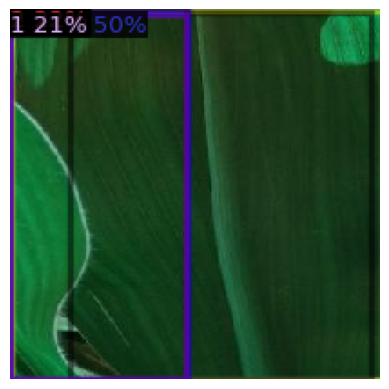

In [ ]:
import glob

# grab any existing image from your train set
test_img = glob.glob(f"{base_path}/train/**/*.jpg", recursive=True)[0]
print("✅ Using test image:", test_img)

image = cv2.imread(test_img)
outputs = predictor(image)

from detectron2.utils.visualizer import Visualizer
import matplotlib.pyplot as plt

v = Visualizer(image[:, :, ::-1], scale=0.8)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
plt.imshow(out.get_image()[:, :, ::-1])
plt.axis("off")
plt.show()


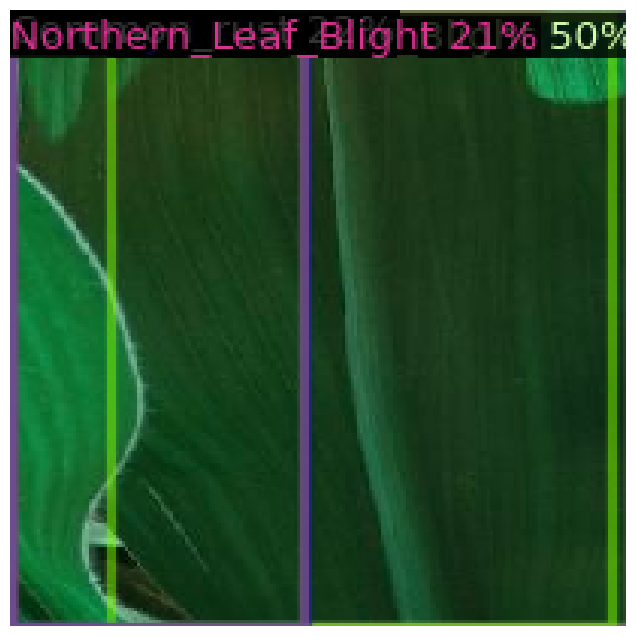

In [ ]:
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog
import matplotlib.pyplot as plt

# Ensure your metadata is linked to your dataset classes
MetadataCatalog.get("maize_train").thing_classes = ["Healthy", "Northern_Leaf_Blight", "Common_rust", "Cercospora_leaf_spot_Gray_leaf_spot"]

# Load the same image again (any image you want to test)
image = cv2.imread(test_img)
outputs = predictor(image)

# Use Visualizer with proper metadata
v = Visualizer(
    image[:, :, ::-1],
    metadata=MetadataCatalog.get("maize_train"),  # 🧠 ensures label names appear
    scale=0.8
)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

plt.figure(figsize=(10, 8))
plt.imshow(out.get_image()[:, :, ::-1])
plt.axis("off")
plt.show()


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving download.jpeg to download.jpeg


In [ ]:
!ls


download.jpeg  drive  sample_data


In [ ]:
!ls -lh


total 24K
-rw-r--r-- 1 root root  15K Oct 31 02:03 download.jpeg
drwx------ 5 root root 4.0K Oct 31 01:45 drive
drwxr-xr-x 1 root root 4.0K Oct 29 13:38 sample_data


In [ ]:
import cv2
img = cv2.imread("download.jpeg")
print("Image:", type(img))


Image: <class 'numpy.ndarray'>


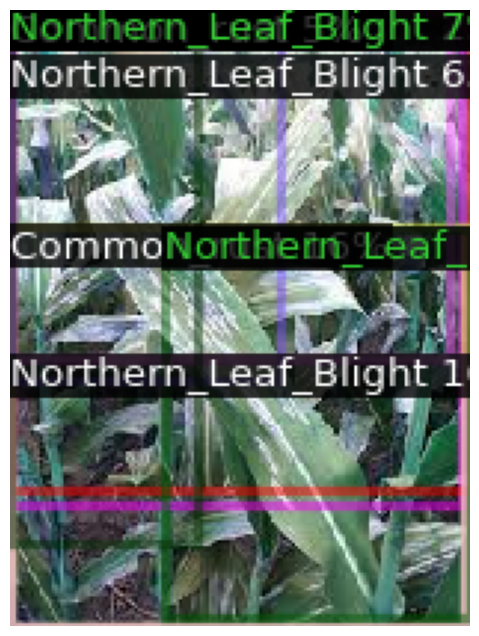

In [ ]:
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog
import matplotlib.pyplot as plt

# Run inference
outputs = predictor(img)

# Visualize
v = Visualizer(img[:, :, ::-1],
               metadata=MetadataCatalog.get("maize_train"),
               scale=0.8)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

plt.figure(figsize=(10, 8))
plt.imshow(out.get_image()[:, :, ::-1])
plt.axis("off")
plt.show()


In [ ]:
import pandas as pd
import json, glob

# load most recent metrics file
log_file = sorted(glob.glob("/content/drive/MyDrive/maize_cls_detectron/output_disease_cls/metrics.json"))[-1]
print("📄 Using log file:", log_file)

# parse safely
records = []
with open(log_file, 'r') as f:
    for line in f:
        records.append(json.loads(line))

df = pd.DataFrame(records)

# show available columns
print("\n📊 Available columns:", list(df.columns))
display(df.tail(10))

# show key metrics if available
key_cols = [col for col in df.columns if any(k in col for k in ["loss", "AP", "iteration", "lr"])]
print("\n📈 Key training columns found:", key_cols)
display(df[key_cols].tail(10))


📄 Using log file: /content/drive/MyDrive/maize_cls_detectron/output_disease_cls/metrics.json

📊 Available columns: ['data_time', 'eta_seconds', 'fast_rcnn/cls_accuracy', 'fast_rcnn/false_negative', 'fast_rcnn/fg_cls_accuracy', 'iteration', 'loss_box_reg', 'loss_cls', 'loss_rpn_cls', 'loss_rpn_loc', 'lr', 'rank_data_time', 'roi_head/num_bg_samples', 'roi_head/num_fg_samples', 'rpn/num_neg_anchors', 'rpn/num_pos_anchors', 'time', 'total_loss']


,data_time,eta_seconds,fast_rcnn/cls_accuracy,fast_rcnn/false_negative,fast_rcnn/fg_cls_accuracy,iteration,loss_box_reg,loss_cls,loss_rpn_cls,loss_rpn_loc,lr,rank_data_time,roi_head/num_bg_samples,roi_head/num_fg_samples,rpn/num_neg_anchors,rpn/num_pos_anchors,time,total_loss
178,0.006328,52.542563,0.945312,0.743464,0.176471,219,0.242973,0.117867,0.001094,0.013106,0.000137,0.006328,119.25,8.75,242.00,14.00,0.297985,0.368249
179,0.005533,46.874802,0.958984,0.531250,0.411765,239,0.222356,0.108236,0.001508,0.013149,0.000149,0.005533,119.50,8.50,243.50,12.50,0.298842,0.345891
180,0.005695,41.238115,0.964844,0.322059,0.486842,259,0.223992,0.104212,0.001983,0.012760,0.000162,0.005695,119.25,8.75,242.00,14.00,0.301638,0.337644
181,0.005718,35.410899,0.970703,0.205263,0.559028,279,0.211716,0.098849,0.001342,0.013018,0.000174,0.005718,119.50,8.50,243.50,12.50,0.300990,0.318300
182,0.005076,29.540698,0.978516,0.088346,0.666667,299,0.185558,0.085192,0.001350,0.012430,0.000187,0.005076,119.50,8.50,243.50,12.50,0.302104,0.284986
183,0.006103,23.677304,0.980469,0.057190,0.718254,319,0.185181,0.078586,0.001350,0.012445,0.000199,0.006103,119.50,8.50,242.75,13.25,0.308314,0.281082
184,0.005874,17.783252,0.976562,0.000000,0.702941,339,0.175977,0.081740,0.001062,0.012110,0.000212,0.005874,119.25,8.75,243.50,12.50,0.300096,0.262409
185,0.006212,11.879192,0.974609,0.000000,0.666667,359,0.150142,0.080705,0.001207,0.012460,0.000224,0.006212,120.00,8.00,242.00,14.00,0.341198,0.246885
186,0.005874,5.947906,0.992188,0.000000,0.928230,379,0.117978,0.063455,0.000795,0.012282,0.000237,0.005874,119.75,8.25,242.75,13.25,0.303389,0.201614
187,0.006315,0.000000,0.988281,0.000000,0.862500,399,0.081605,0.058180,0.001985,0.012245,0.000249,0.006315,119.50,8.50,243.50,12.50,0.302152,0.155371



📈 Key training columns found: ['iteration', 'loss_box_reg', 'loss_cls', 'loss_rpn_cls', 'loss_rpn_loc', 'lr', 'total_loss']


,iteration,loss_box_reg,loss_cls,loss_rpn_cls,loss_rpn_loc,lr,total_loss
178,219,0.242973,0.117867,0.001094,0.013106,0.000137,0.368249
179,239,0.222356,0.108236,0.001508,0.013149,0.000149,0.345891
180,259,0.223992,0.104212,0.001983,0.012760,0.000162,0.337644
181,279,0.211716,0.098849,0.001342,0.013018,0.000174,0.318300
182,299,0.185558,0.085192,0.001350,0.012430,0.000187,0.284986
183,319,0.185181,0.078586,0.001350,0.012445,0.000199,0.281082
184,339,0.175977,0.081740,0.001062,0.012110,0.000212,0.262409
185,359,0.150142,0.080705,0.001207,0.012460,0.000224,0.246885
186,379,0.117978,0.063455,0.000795,0.012282,0.000237,0.201614
187,399,0.081605,0.058180,0.001985,0.012245,0.000249,0.155371


In [ ]:
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader

evaluator = COCOEvaluator("maize_train", cfg, False, output_dir=cfg.OUTPUT_DIR)
val_loader = build_detection_test_loader(cfg, "maize_train")
results = inference_on_dataset(trainer.model, val_loader, evaluator)
print("📊 Validation Results:", results)


WARNING [10/31 02:14:53 d2.evaluation.coco_evaluation]: COCO Evaluator instantiated using config, this is deprecated behavior. Please pass in explicit arguments instead.
[10/31 02:14:53 d2.evaluation.coco_evaluation]: Trying to convert 'maize_train' to COCO format ...
[10/31 02:14:53 d2.data.datasets.coco]: Converting annotations of dataset 'maize_train' to COCO format ...)
⚠️ Skipping missing class folder: Cercospora_leaf_spot_Gray_leaf_spot
[10/31 02:15:59 d2.data.datasets.coco]: Converting dataset dicts into COCO format
[10/31 02:16:00 d2.data.datasets.coco]: Conversion finished, #images: 5674, #annotations: 5674
[10/31 02:16:00 d2.data.datasets.coco]: Caching COCO format annotations at '/content/drive/MyDrive/maize_cls_detectron/output_disease_cls/maize_train_coco_format.json' ...
⚠️ Skipping missing class folder: Cercospora_leaf_spot_Gray_leaf_spot
[10/31 02:16:28 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 

In [ ]:
import shutil, os, datetime

base_dir = "/content/drive/MyDrive/maize_cls_detectron"
backup_dir = os.path.join(base_dir, f"backup_{datetime.datetime.now().strftime('%Y%m%d_%H%M')}")

os.makedirs(backup_dir, exist_ok=True)

# Copy key outputs
for item in ["output_disease_cls", "detectron_cfg.yaml"]:
    src = os.path.join(base_dir, item)
    if os.path.exists(src):
        dst = os.path.join(backup_dir, item)
        shutil.copytree(src, dst, dirs_exist_ok=True)

# Save notebook if in Colab
try:
    from google.colab import drive
    shutil.copy("/content/*.ipynb", backup_dir)
except:
    pass

print("✅ Backup complete at:", backup_dir)


✅ Backup complete at: /content/drive/MyDrive/maize_cls_detectron/backup_20251031_0224


In [ ]:
# Save Detectron config
with open(f"{base_dir}/detectron_cfg.yaml", "w") as f:
    f.write(cfg.dump())

# Save model checkpoint (already saved, but ensure copy)
shutil.copy(f"{cfg.OUTPUT_DIR}/model_final.pth", f"{base_dir}/model_final.pth")
print("✅ Config + model saved for future use.")


✅ Config + model saved for future use.
